In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mysql.connector


db = mysql.connector.connect(host = "localhost", 
                             username = "root", 
                             password = "12345", 
                             database = "ecommerce")

cur = db.cursor()

# List all unique cities where customers are located.

In [ ]:
query = "SELECT DISTINCT customer_city FROM customers"

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Customer_city"])
print(df.head(10))

           Customer_city
0                 franca
1  sao bernardo do campo
2              sao paulo
3        mogi das cruzes
4               campinas
5         jaragua do sul
6                timoteo
7               curitiba
8         belo horizonte
9          montes claros


# Count the number of orders placed in 2017.

In [ ]:
query = "SELECT COUNT(order_id) FROM orders WHERE YEAR(order_purchase_timestamp) = 2017"

cur.execute(query)
data = cur.fetchall()

print("Total orders placed in 2017 are : ", data[0][0])

Total orders placed in 2017 are :  45101


# Find the total sales per category.

In [ ]:
query = """select products.product_category_name as categories, 
round(sum(order_payments.payment_value),2) as sales 
from products join order_items 
on products.product_id = order_items.product_id
join order_payments 
on order_payments.order_id = order_items.order_id 
group by categories
order by sales desc"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data , columns = ["category","sales"])
print(df.head(10))

                 category       sales
0         cama_mesa_banho  1712553.67
1            beleza_saude  1657373.12
2  informatica_acessorios  1585330.45
3        moveis_decoracao  1430176.39
4      relogios_presentes  1429216.68
5           esporte_lazer  1392127.56
6   utilidades_domesticas  1094758.13
7              automotivo   852294.33
8      ferramentas_jardim   838280.75
9              cool_stuff   779698.00


# Calculate the percentage of orders that were paid in installments.

In [ ]:
query = "select ((sum(case when payment_installments >= 1 then 1 else 0 end))/count(*))*100 from order_payments"

cur.execute(query)
data = cur.fetchall()

print("the percentage of orders that were paid in installments is", data[0][0])


the percentage of orders that were paid in installments is 99.9981


# Count the number of customers from each state.

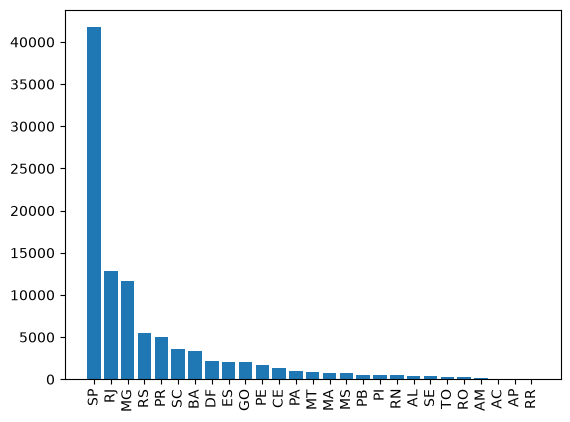

In [ ]:
query = "select customer_state, count(customer_id) from customers group by customer_state"

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["state", "customer_count"])
df = df.sort_values(by = "customer_count" , ascending = False)

plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation = 90)
plt.show()

# Calculate the number of orders per month in 2018.

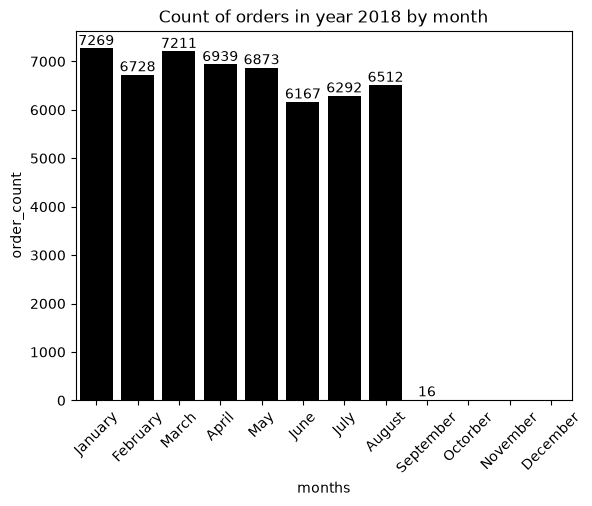

In [ ]:
query = """select monthname(order_purchase_timestamp) as months, 
count(order_id) as order_count 
from orders 
where year(order_purchase_timestamp) = "2018" 
group by months
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["months","order_count"])
o = ["January", "February", "March","April", "May", "June", "July", "August", "September", "Octorber", "November", "December"]

ax = sns.barplot(x = df["months"] , y = df["order_count"] , data = df , order = o , color = "black")
ax.bar_label(ax.containers[0])
plt.xticks(rotation = 45)
plt.title("Count of orders in year 2018 by month")
plt.show()

# Find the average number of products per order, grouped by customer city.

In [ ]:
query = """with count_per_order as 
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc 
from orders join order_items 
on orders.order_id = order_items.order_id 
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) 
from customers join count_per_order 
on customers.customer_id = count_per_order.customer_id 
group by customers.customer_city"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Customer_city","Avg_orders"])
print(df.head(10))

         Customer_city Avg_orders
0            sao paulo       1.16
1  sao jose dos campos       1.14
2         porto alegre       1.17
3              indaial       1.12
4         treze tilias       1.27
5       rio de janeiro       1.15
6         mario campos       1.33
7              guariba       1.00
8               cuiaba       1.20
9               franca       1.25


# Calculate the percentage of total revenue contributed by each product category.

In [ ]:
query = """select upper(name_translation.product_category_name_english) as category, 
round((sum(order_payments.payment_value)/(select sum(payment_value) from order_payments))*100,2) as sales_percentage
from name_translation join products
on name_translation.product_category_name = products.product_category_name 
join order_items 
on products.product_id = order_items.product_id
join order_payments 
on order_items.order_id = order_payments.order_id
group by category
order by sales_percentage desc"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Sales_percentage"])
print(df.head(10))


                Category  Sales_percentage
0         BED_BATH_TABLE             10.70
1          HEALTH_BEAUTY             10.35
2  COMPUTERS_ACCESSORIES              9.90
3        FURNITURE_DECOR              8.93
4          WATCHES_GIFTS              8.93
5         SPORTS_LEISURE              8.70
6             HOUSEWARES              6.84
7                   AUTO              5.32
8           GARDEN_TOOLS              5.24
9             COOL_STUFF              4.87


# Identify the correlation between product price and the number of times a product has been purchased.

In [ ]:
query = """select products.product_category_name, 
count(order_items.product_id), 
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category_name"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "order_count","price"])
print(df.head(10))

arr1 = df["order_count"]
arr2 = df["price"]
a = np.corrcoef([arr1,arr2])

print("\n\nThe Correlation coefficient is : ",a[0][-1])


                 Category  order_count   price
0            beleza_saude         9670  130.16
1           esporte_lazer         8641  114.34
2              cool_stuff         3796  167.36
3  informatica_acessorios         7827  116.51
4      relogios_presentes         5991  201.14
5   utilidades_domesticas         6964   90.79
6             eletronicos         2767   57.91
7                     NaN         1603  112.00
8              brinquedos         4117  117.55
9         cama_mesa_banho        11115   93.30


The Correlation coefficient is :  -0.10631514167157562


# Calculate the total revenue generated by each seller, and rank them by revenue.

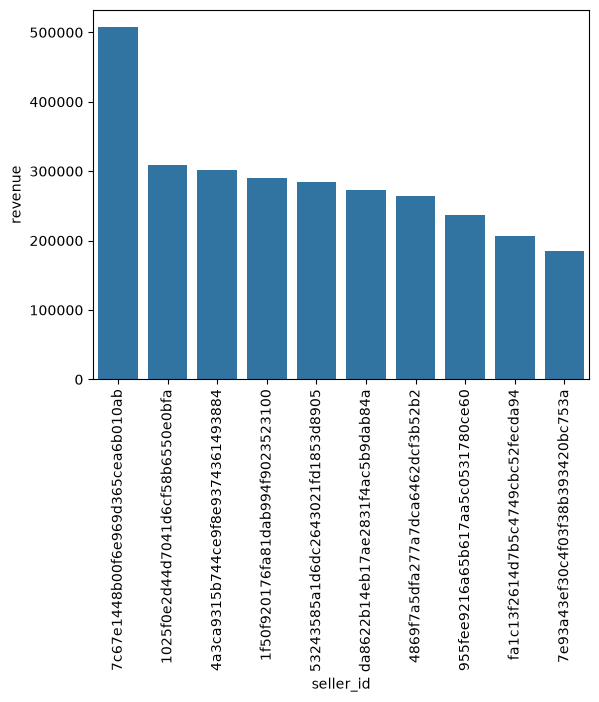

In [ ]:
query = """select *, dense_rank() over (order by revenue desc) as rn
from (select order_items.seller_id, round(sum(order_payments.payment_value),2) as revenue 
from order_items join order_payments
on order_items.order_id = order_payments.order_id
group by order_items.seller_id) as a"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["seller_id", "revenue","rank"])
df = df.head(10)
sns.barplot(x = "seller_id", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [17]:
query = """select customer_id, opt, payment,
avg(payment) over(partition by customer_id order by opt
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp as opt, order_payments.payment_value as payment
from orders join order_payments
on orders.order_id = order_payments.order_id) as a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_id", "order_purchase_timestamp", "payment", "mov_avg"])
df

,customer_id,order_purchase_timestamp,payment,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# Calculate the cumulative sales per month for each year.

In [22]:
query = """select yr, mon, payment, sum(payment) over(order by yr, mon) 
from
(select year(orders.order_purchase_timestamp) as yr, month(orders.order_purchase_timestamp) as mon, round(sum(order_payments.payment_value),2) as payment
from orders join order_payments
on orders.order_id = order_payments.order_id
group by yr, mon
order by yr)
as a"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Year", "Month", "Payment_in_a_month", "Cumulative sales"])
print(df)

    Year  Month  Payment_in_a_month  Cumulative sales
0   2016      9              252.24            252.24
1   2016     10            59090.48          59342.72
2   2016     12               19.62          59362.34
3   2017      1           138488.04         197850.38
4   2017      2           291908.01         489758.39
5   2017      3           449863.60         939621.99
6   2017      4           417788.03        1357410.02
7   2017      5           592918.82        1950328.84
8   2017      6           511276.38        2461605.22
9   2017      7           592382.92        3053988.14
10  2017      8           674396.32        3728384.46
11  2017      9           727762.45        4456146.91
12  2017     10           779677.88        5235824.79
13  2017     11          1194882.80        6430707.59
14  2017     12           878401.48        7309109.07
15  2018      1          1115004.18        8424113.25
16  2018      2           992463.34        9416576.59
17  2018      3          115

# Calculate the year-over-year growth rate of total sales.

In [24]:
query = """with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(order_payments.payment_value),2) as payment 
from orders join order_payments
on orders.order_id = order_payments.order_id
group by years 
order by years)
select years, ((payment - lag(payment, 1) over(order by years))/
lag(payment, 1) over(order by years)) * 100 from a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [25]:
query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id) 

select 100 * (count( distinct a.customer_id)/ count(distinct b.customer_id)) 
from a left join b 
on a.customer_id = b.customer_id ;"""

cur.execute(query)
data = cur.fetchall()

data

[(None,)]

# Identify the top 3 customers who spent the most money in each year.

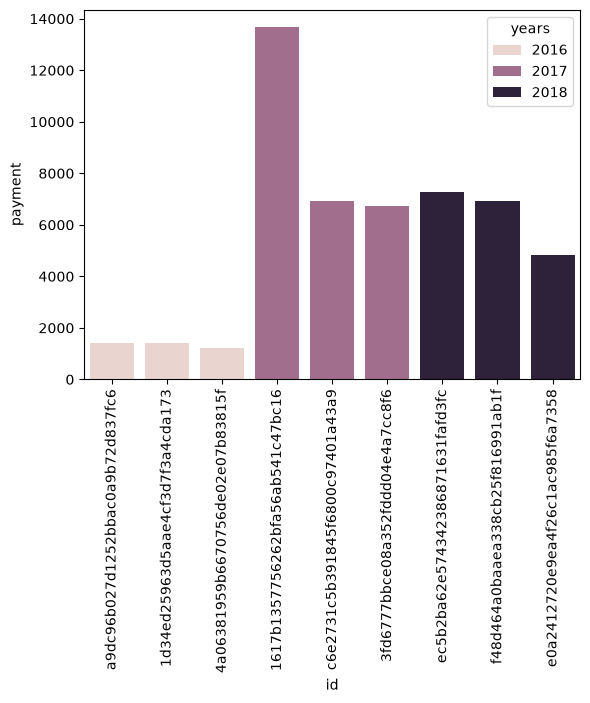

In [26]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(order_payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(order_payments.payment_value) desc) d_rank
from orders join order_payments 
on order_payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 ;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","id","payment","rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()